In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, LSTM, Bidirectional,
                                     Conv1D, MaxPooling1D,
                                     BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"diabetes.csv")


In [3]:
df2 = pd.read_csv("diabetes.csv")
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df2[col] = df2[col].replace(0, df2[col].mean())

In [4]:
X = df2.drop(['Outcome'], axis=1).values
y = df2['Outcome'].values
 

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42
)

In [7]:
X_train_seq = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_seq  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])
 
n_features = X_train.shape[1]   # 8
 
# Callback shared across models
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True)
 
# Dictionary to collect results for comparison plots
results = {}   # { model_name: { 'y_pred': ..., 'y_prob': ... } }

In [9]:
print("=" * 55)
print("  Training DNN")
print("=" * 55)
 
dnn = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='DNN')
 
dnn.compile(optimizer=Adam(1e-3), loss='binary_crossentropy',
            metrics=['accuracy'])
dnn.summary()
 
dnn.fit(X_train, y_train, epochs=100, batch_size=32,
        validation_split=0.1, callbacks=[early_stop], verbose=1)
 
dnn_prob  = dnn.predict(X_train).ravel()
dnn_prob  = dnn.predict(X_test).ravel()
dnn_pred  = (dnn_prob >= 0.5).astype(int)
 
print(f"\nDNN  Training Accuracy : {dnn.evaluate(X_train, y_train, verbose=0)[1]:.4f}")
print(f"DNN  Testing  Accuracy : {dnn.evaluate(X_test,  y_test,  verbose=0)[1]:.4f}")
print("\nClassification Report:\n", classification_report(y_test, dnn_pred))
 
results['DNN'] = {'y_pred': dnn_pred, 'y_prob': dnn_prob}
 

  Training DNN


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6312 - loss: 0.6885 - val_accuracy: 0.7143 - val_loss: 0.6245
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7407 - loss: 0.5468 - val_accuracy: 0.7143 - val_loss: 0.5945
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7279 - loss: 0.5335 - val_accuracy: 0.7143 - val_loss: 0.5694
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7552 - loss: 0.5095 - val_accuracy: 0.7429 - val_loss: 0.5578
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7166 - loss: 0.5363 - val_accuracy: 0.7429 - val_loss: 0.5467
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7794 - loss: 0.4974 - val_accuracy: 0.7571 - val_loss: 0.5320
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7585 - loss: 0.4802 - val_accuracy: 0.7286 - val_loss: 0.5233
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7601 - loss: 0.5170 - val_accuracy: 0.7286 

In [10]:
print("=" * 55)
print("  Training BiLSTM")
print("=" * 55)
 
bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(1, n_features)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='BiLSTM')
 
bilstm.compile(optimizer=Adam(1e-3), loss='binary_crossentropy',
               metrics=['accuracy'])
bilstm.summary()
 
bilstm.fit(X_train_seq, y_train, epochs=100, batch_size=32,
           validation_split=0.1, callbacks=[early_stop], verbose=1)
 
bilstm_prob = bilstm.predict(X_test_seq).ravel()
bilstm_pred = (bilstm_prob >= 0.5).astype(int)
 
print(f"\nBiLSTM  Training Accuracy : {bilstm.evaluate(X_train_seq, y_train, verbose=0)[1]:.4f}")
print(f"BiLSTM  Testing  Accuracy : {bilstm.evaluate(X_test_seq,  y_test,  verbose=0)[1]:.4f}")
print("\nClassification Report:\n", classification_report(y_test, bilstm_pred))
 
results['BiLSTM'] = {'y_pred': bilstm_pred, 'y_prob': bilstm_prob}
 

  Training BiLSTM


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 128)         │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,649 (311.13 KB)

 Trainable params: 79,649 (311.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.6747 - loss: 0.6788 - val_accuracy: 0.7286 - val_loss: 0.6607
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7649 - loss: 0.6284 - val_accuracy: 0.7000 - val_loss: 0.5966
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7681 - loss: 0.5435 - val_accuracy: 0.7286 - val_loss: 0.5145
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7746 - loss: 0.4826 - val_accuracy: 0.7286 - val_loss: 0.4751
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7746 - loss: 0.4684 - val_accuracy: 0.7429 - val_loss: 0.4566
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7890 - loss: 0.4546 - val_accuracy: 0.7286 - val_loss: 0.4463
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7842 - loss: 0.4555 - val_accuracy: 0.7571 - val_loss: 0.4466
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7874 - loss: 0.4452 - val_accuracy: 0.7571

In [12]:
print("=" * 55)
print("  Training TabNet")
print("=" * 55)
 
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "pytorch-tabnet", "-q"])
 
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
 
tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.3,
    n_independent=2, n_shared=2,
    momentum=0.02, epsilon=1e-15,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 50, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax', verbose=1, seed=42
)
 
tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=['accuracy'],
    max_epochs=200, patience=20,
    batch_size=256, virtual_batch_size=128,
)
 
tabnet_pred = tabnet.predict(X_test)
tabnet_prob = tabnet.predict_proba(X_test)[:, 1]
 
print(f"\nTabNet  Training Accuracy : {(tabnet.predict(X_train) == y_train).mean():.4f}")
print(f"TabNet  Testing  Accuracy : {(tabnet_pred == y_test).mean():.4f}")
print("\nClassification Report:\n", classification_report(y_test, tabnet_pred))
 
results['TabNet'] = {'y_pred': tabnet_pred, 'y_prob': tabnet_prob}
 
 

  Training TabNet
epoch 0  | loss: 0.90101 | val_0_accuracy: 0.67532 |  0:00:00s
epoch 1  | loss: 0.64735 | val_0_accuracy: 0.66234 |  0:00:00s
epoch 2  | loss: 0.60031 | val_0_accuracy: 0.71429 |  0:00:00s
epoch 3  | loss: 0.53415 | val_0_accuracy: 0.63636 |  0:00:00s
epoch 4  | loss: 0.48717 | val_0_accuracy: 0.62338 |  0:00:00s
epoch 5  | loss: 0.48303 | val_0_accuracy: 0.62338 |  0:00:00s
epoch 6  | loss: 0.45236 | val_0_accuracy: 0.63636 |  0:00:00s
epoch 7  | loss: 0.49864 | val_0_accuracy: 0.64935 |  0:00:00s
epoch 8  | loss: 0.47319 | val_0_accuracy: 0.66234 |  0:00:00s
epoch 9  | loss: 0.45241 | val_0_accuracy: 0.72727 |  0:00:01s
epoch 10 | loss: 0.4613  | val_0_accuracy: 0.75325 |  0:00:01s
epoch 11 | loss: 0.44376 | val_0_accuracy: 0.71429 |  0:00:01s
epoch 12 | loss: 0.45269 | val_0_accuracy: 0.72727 |  0:00:01s
epoch 13 | loss: 0.43208 | val_0_accuracy: 0.72727 |  0:00:01s
epoch 14 | loss: 0.42038 | val_0_accuracy: 0.72727 |  0:00:01s
epoch 15 | loss: 0.41065 | val_0_accu

In [13]:
print("=" * 55)
print("  Training DT + DNN Hybrid")
print("=" * 55)
 
# ── Step 1: Train Decision Tree ──────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
 
dt_train_acc = dt.score(X_train, y_train)
dt_test_acc  = dt.score(X_test,  y_test)
print(f"  DT alone  Train : {dt_train_acc:.4f}   Test : {dt_test_acc:.4f}")
 
# ── Step 2: Extract leaf indices → One-Hot Encode ────────────
leaf_train = dt.apply(X_train).reshape(-1, 1)
leaf_test  = dt.apply(X_test).reshape(-1, 1)
 
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(leaf_train)
 
leaf_train_ohe = ohe.transform(leaf_train)
leaf_test_ohe  = ohe.transform(leaf_test)
 
print(f"  Raw features      : {X_train.shape[1]}")
print(f"  Leaf OHE features : {leaf_train_ohe.shape[1]}")
 
# ── Step 3: Concatenate ───────────────────────────────────────
X_train_hybrid = np.hstack([X_train, leaf_train_ohe])
X_test_hybrid  = np.hstack([X_test,  leaf_test_ohe])
input_dim      = X_train_hybrid.shape[1]
print(f"  Combined input    : {input_dim}")
 
# ── Step 4: Build & Train DNN on enriched features ───────────
dt_dnn = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.35),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='DT_DNN_Hybrid')
 
dt_dnn.compile(optimizer=Adam(1e-3), loss='binary_crossentropy',
               metrics=['accuracy'])
dt_dnn.summary()
 
early_stop2 = EarlyStopping(monitor='val_loss', patience=12,
                            restore_best_weights=True)
 
dt_dnn.fit(X_train_hybrid, y_train, epochs=150, batch_size=32,
           validation_split=0.1, callbacks=[early_stop2], verbose=1)
 
hybrid_prob = dt_dnn.predict(X_test_hybrid).ravel()
hybrid_pred = (hybrid_prob >= 0.5).astype(int)
 
print(f"\nDT+DNN  Training Accuracy : {dt_dnn.evaluate(X_train_hybrid, y_train, verbose=0)[1]:.4f}")
print(f"DT+DNN  Testing  Accuracy : {dt_dnn.evaluate(X_test_hybrid,  y_test,  verbose=0)[1]:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, hybrid_pred,
                            target_names=['No Diabetes', 'Diabetes']))
 
results['DT+DNN'] = {'y_pred': hybrid_pred, 'y_prob': hybrid_prob}
 
 

  Training DT + DNN Hybrid
  DT alone  Train : 0.8437   Test : 0.7662
  Raw features      : 8
  Leaf OHE features : 26
  Combined input    : 34


Model: "DT_DNN_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,761 (210.00 KB)

 Trainable params: 52,993 (207.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6361 - loss: 0.6419 - val_accuracy: 0.6714 - val_loss: 0.6194
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7327 - loss: 0.5034 - val_accuracy: 0.7143 - val_loss: 0.5907
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7810 - loss: 0.4453 - val_accuracy: 0.7429 - val_loss: 0.5739
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7971 - loss: 0.4200 - val_accuracy: 0.7857 - val_loss: 0.5436
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8116 - loss: 0.4203 - val_accuracy: 0.8286 - val_loss: 0.5323
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8180 - loss: 0.4273 - val_accuracy: 0.8143 - val_loss: 0.5275
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7987 - loss: 0.3908 - val_accuracy: 0.8429 - val_loss: 0.5193
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8180 - loss: 0.3878 - val_accuracy: 0.8143 

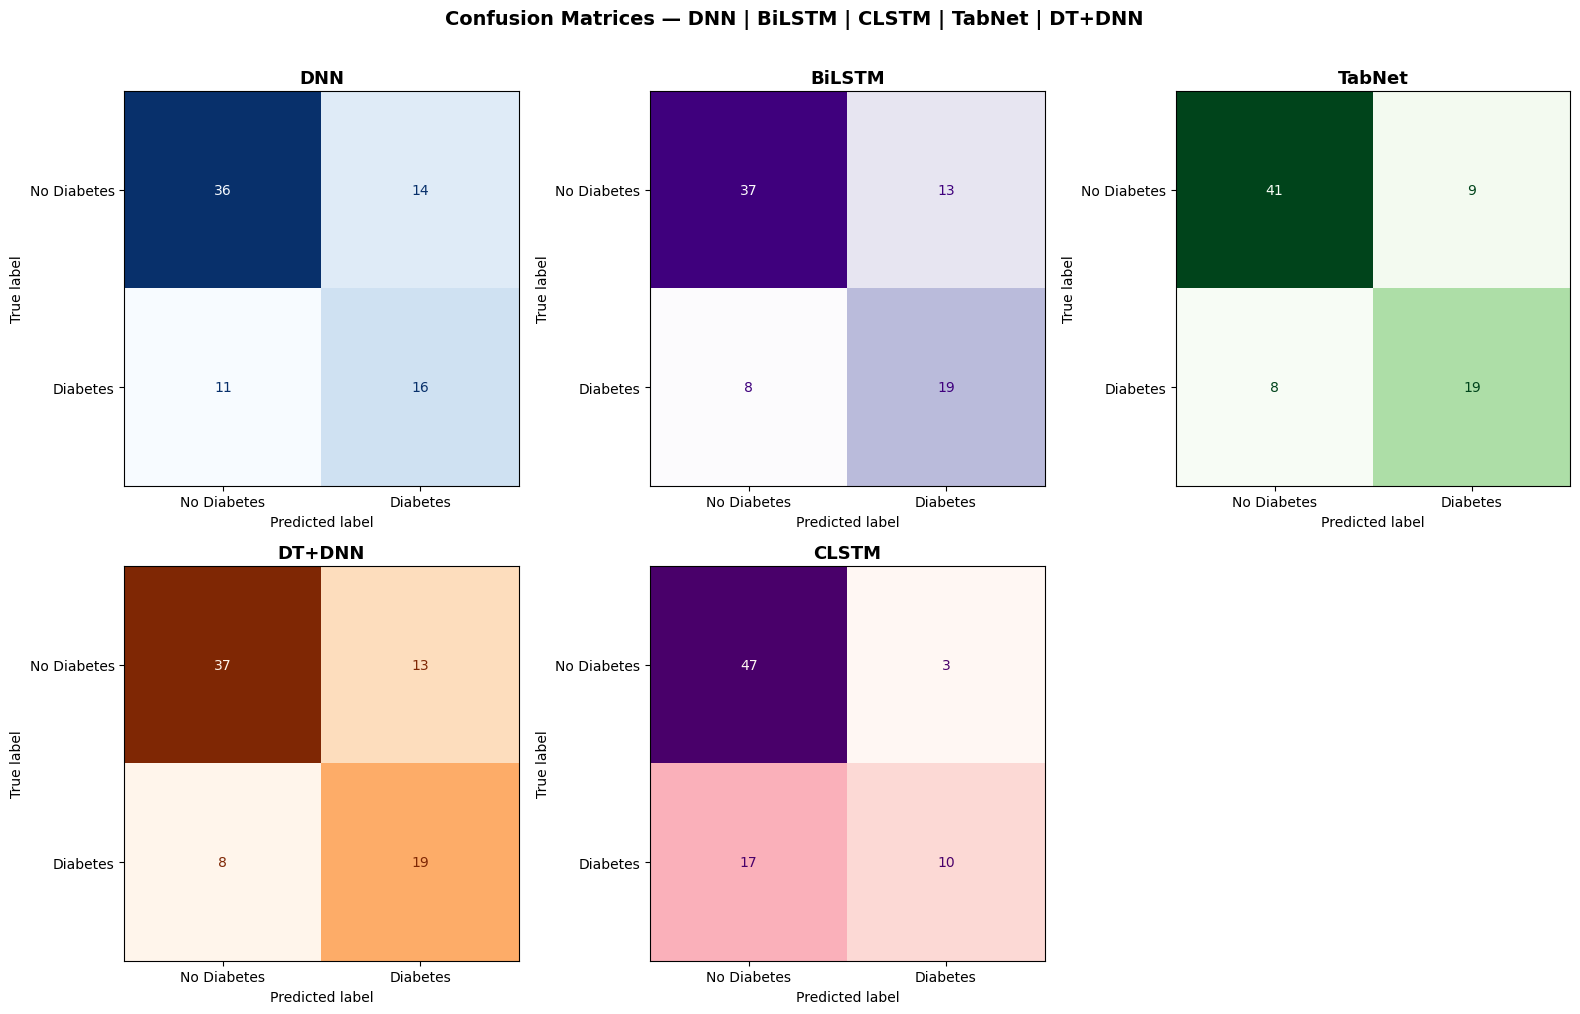

Saved → confusion_matrices_all.png


In [17]:
n_models = len(results)    # 5
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
 
colors = ['Blues', 'Purples', 'Greens', 'Oranges', 'RdPu']
 
for idx, ((model_name, res), cmap) in enumerate(zip(results.items(), colors)):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap=cmap)
    axes[idx].set_title(f'{model_name}', fontsize=13, fontweight='bold')
 
# Hide the unused 6th subplot
axes[-1].set_visible(False)
 
plt.suptitle('Confusion Matrices — DNN | BiLSTM | CLSTM | TabNet | DT+DNN',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → confusion_matrices_all.png")
 

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — CNN + LSTM Hybrid (CLSTM)
# ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  Training CLSTM (CNN + LSTM hybrid)")
print("=" * 55)
 
# Reshape to (samples, timesteps=8, channels=1) so Conv1D can work
X_train_cnn = X_train.reshape(X_train.shape[0], n_features, 1)
X_test_cnn  = X_test.reshape(X_test.shape[0],  n_features, 1)
 
clstm = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same',
           input_shape=(n_features, 1)),
    BatchNormalization(),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='CLSTM')
 
clstm.compile(optimizer=Adam(1e-3), loss='binary_crossentropy',
              metrics=['accuracy'])
clstm.summary()
 
history_clstm = clstm.fit(
    X_train_cnn, y_train,
    epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
 
clstm_prob  = clstm.predict(X_test_cnn).ravel()
clstm_pred  = (clstm_prob >= 0.5).astype(int)
clstm_train_acc = clstm.evaluate(X_train_cnn, y_train, verbose=0)[1]
clstm_test_acc  = clstm.evaluate(X_test_cnn,  y_test,  verbose=0)[1]
 
print(f"\nCLSTM  Training Accuracy : {clstm_train_acc:.4f}")
print(f"CLSTM  Testing  Accuracy : {clstm_test_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, clstm_pred))
 
results['CLSTM'] = {'y_pred': clstm_pred, 'y_prob': clstm_prob}
 
 

  Training CLSTM (CNN + LSTM hybrid)


Model: "CLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 8, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,633 (131.38 KB)

 Trainable params: 33,505 (130.88 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6747 - loss: 0.6158 - val_accuracy: 0.7286 - val_loss: 0.6394
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7166 - loss: 0.5369 - val_accuracy: 0.7571 - val_loss: 0.6045
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7262 - loss: 0.5225 - val_accuracy: 0.7571 - val_loss: 0.6187
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7504 - loss: 0.4886 - val_accuracy: 0.7571 - val_loss: 0.5892
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7456 - loss: 0.4965 - val_accuracy: 0.7429 - val_loss: 0.5946
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7359 - loss: 0.5064 - val_accuracy: 0.7571 - val_loss: 0.5820
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7617 - loss: 0.4761 - val_accuracy: 0.7286 - val_loss: 0.5732
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7488 - loss: 0.4924 - val_accuracy: 0.

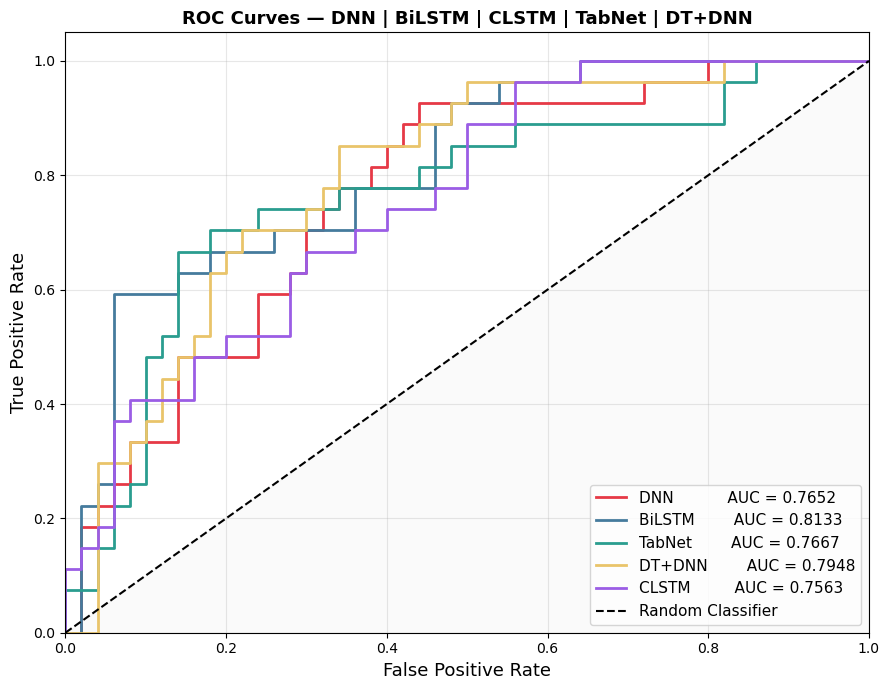

Saved → roc_auc_all.png


In [15]:
plt.figure(figsize=(9, 7))
 
palette = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#9b5de5']
 
for (model_name, res), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{model_name:<12}  AUC = {roc_auc:.4f}')
 
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
plt.xlim([0.0, 1.0]);  plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate',  fontsize=13)
plt.title('ROC Curves — DNN | BiLSTM | CLSTM | TabNet | DT+DNN',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → roc_auc_all.png")
 
 


── Model Performance Summary ──
 Model    AUC  Accuracy
   DNN 0.7652    0.6753
BiLSTM 0.8133    0.7273
TabNet 0.7667    0.7792
DT+DNN 0.7948    0.7273
 CLSTM 0.7563    0.7403


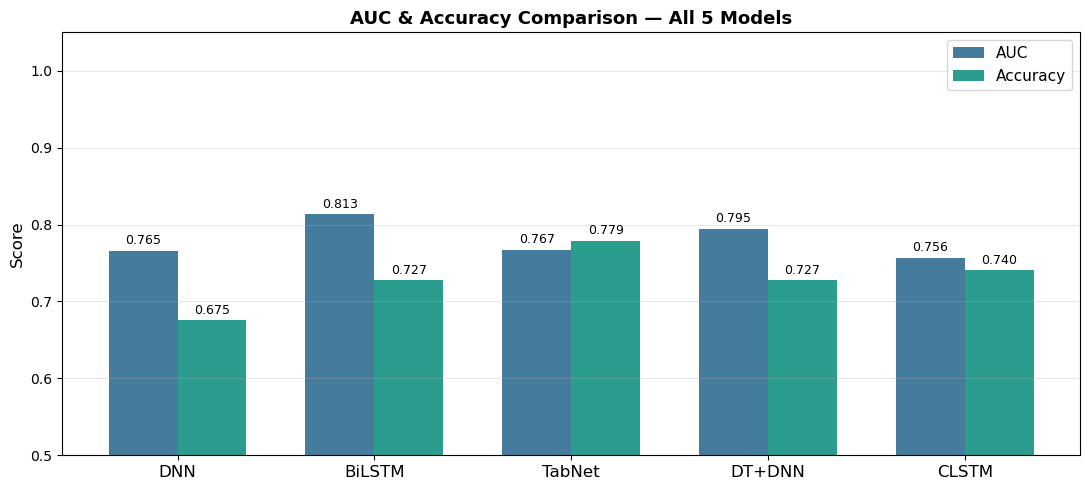

Saved → auc_accuracy_all.png


In [16]:
model_names, auc_scores, acc_scores = [], [], []
 
for model_name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    model_names.append(model_name)
    auc_scores.append(round(auc(fpr, tpr), 4))
    acc_scores.append(round((res['y_pred'] == y_test).mean(), 4))
 
summary_df = pd.DataFrame({
    'Model'   : model_names,
    'AUC'     : auc_scores,
    'Accuracy': acc_scores
})
print("\n── Model Performance Summary ──")
print(summary_df.to_string(index=False))
 
x     = np.arange(len(model_names))
width = 0.35
 
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, auc_scores, width, label='AUC',      color='#457b9d')
bars2 = ax.bar(x + width/2, acc_scores, width, label='Accuracy', color='#2a9d8f')
 
ax.set_ylim(0.5, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('AUC & Accuracy Comparison — All 5 Models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
 
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.savefig('auc_accuracy_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → auc_accuracy_all.png")

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# 1. Ensure the results dictionary contains all 5 models with correct variables
# (This step re-assigns them correctly to avoid NameErrors)
results['DNN'] = {'y_pred': (dnn.predict(X_test).ravel() >= 0.5).astype(int)}
results['Bi-LSTM'] = {'y_pred': (bilstm.predict(X_test_seq).ravel() >= 0.5).astype(int)}
results['CLSTM'] = {'y_pred': (clstm.predict(X_test_cnn).ravel() >= 0.5).astype(int)}
results['TabNet'] = {'y_pred': tabnet.predict(X_test)}
results['DT+DNN'] = {'y_pred': (dt_dnn.predict(X_test_hybrid).ravel() >= 0.5).astype(int)}

# 2. Calculate metrics for all 5
final_metrics = []

for model_name, data in results.items():
    y_pred = data['y_pred']
    final_metrics.append({
        'Algorithm': model_name,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    })

# 3. Display the final table
comparison_df = pd.DataFrame(final_metrics)
print("--- Performance Metrics for All 5 Algorithms ---")
print(comparison_df)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
--- Performance Metrics for All 5 Algorithms ---
  Algorithm  Precision  Recall  F1-Score
0       DNN     0.5333  0.5926    0.5614
1   Bi-LSTM     0.5938  0.7037    0.6441
2    DT+DNN     0.5938  0.7037    0.6441
3     CLSTM     0.7692  0.3704    0.5000
4    TabNet     0.6786  0.7037    0.6909
